# Data Preprocessing

Prepare two datasets from PCB images and bounding boxes:
- **Object Detection:** 640×640 RGB images and YOLO labels.
- **Image Classification:** 224×224 defect crops and class labels.

## 1. Setup

Set `REBUILD_OUTPUT = True` only when you want to replace existing processed datasets.

In [17]:
import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

SPLITS = ["train", "valid", "test"]
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
IMAGE_SIZE = 640
CROP_SIZE = 224
REBUILD_OUTPUT = False

RAW_DIR = Path("Data/raw_data")
if not (RAW_DIR / "Class.txt").exists():
    RAW_DIR = RAW_DIR / "DeepPCB"

DETECT_ROOT = Path("Data/processed/detection")
CROP_ROOT = Path("Data/processed/classification")

BAD_IMAGE = "01_PCB__1030.jpg"
CONTEXT_LEVELS = [(0.75, 96), (0.50, 80), (0.35, 64), (0.25, 48), (0.10, 32)]
MIN_MARGIN_RATIO = 0.10
RESAMPLE = Image.Resampling.BICUBIC if hasattr(Image, "Resampling") else Image.BICUBIC

if not (RAW_DIR / "Class.txt").exists():
    raise FileNotFoundError("Class.txt not found")

print("Source:", RAW_DIR)
print("Detection:", DETECT_ROOT)
print("Classification:", CROP_ROOT)

Source: Data\raw_data
Detection: Data\processed\detection
Classification: Data\processed\classification


## 2. Remove the invalid image

Delete `01_PCB__1030.jpg` and its annotation from the raw dataset before processing. This deletion is permanent.

In [18]:
for split in SPLITS:
    image_path = RAW_DIR / split / "images" / BAD_IMAGE
    label_path = RAW_DIR / split / "labels" / (Path(BAD_IMAGE).stem + ".txt")

    if image_path.exists():
        image_path.unlink()
        print("Removed:", image_path)

    if label_path.exists():
        label_path.unlink()
        print("Removed:", label_path)

Removed: Data\raw_data\train\images\01_PCB__1030.jpg
Removed: Data\raw_data\train\labels\01_PCB__1030.txt


## 3. Read and check the raw dataset

Read the class names, images and bounding boxes. Each label line contains `x1 y1 x2 y2 class_id`.

In [19]:
text = (RAW_DIR / "Class.txt").read_text(encoding="utf-8")
class_names = []
for name in text.replace("\n", ",").split(","):
    name = name.strip().strip("\"'")
    if name:
        class_names.append(name)

if not class_names or len(class_names) != len(set(class_names)):
    raise ValueError("Invalid class names")

image_rows = []
box_rows = []

for split in SPLITS:
    image_dir = RAW_DIR / split / "images"
    label_dir = RAW_DIR / split / "labels"

    if not image_dir.is_dir() or not label_dir.is_dir():
        raise FileNotFoundError(f"Missing images or labels folder: {split}")

    images = []
    for path in sorted(image_dir.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            images.append(path)

    if not images:
        raise ValueError(f"No images in {split}")

    image_names = [path.stem for path in images]
    if len(image_names) != len(set(image_names)):
        raise ValueError(f"Duplicate image names in {split}")

    for label_path in label_dir.glob("*.txt"):
        if label_path.stem not in image_names:
            raise ValueError(f"Label without image: {label_path}")

    for image_path in images:
        label_path = label_dir / (image_path.stem + ".txt")
        if not label_path.exists():
            raise FileNotFoundError(f"Missing label: {label_path}")

        with Image.open(image_path) as image:
            width, height = image.size
            image_mode = image.mode
            image.load()

        if width != IMAGE_SIZE or height != IMAGE_SIZE:
            raise ValueError(f"Invalid image size: {image_path}")

        image_rows.append({
            "split": split, "image_name": image_path.name,
            "source_path": str(image_path), "source_mode": image_mode,
            "source_width": width, "source_height": height
        })

        lines = label_path.read_text(encoding="utf-8").splitlines()
        for line_number, line in enumerate(lines, start=1):
            if not line.strip():
                continue

            values = line.split()
            if len(values) != 5:
                raise ValueError(f"Invalid label format: {label_path}, line {line_number}")

            try:
                x1, y1, x2, y2, class_id = [int(value) for value in values]
            except ValueError:
                raise ValueError(f"Invalid label values: {label_path}, line {line_number}")

            if not (0 <= x1 < x2 <= width and 0 <= y1 < y2 <= height):
                raise ValueError(f"Invalid box: {label_path}, line {line_number}")

            box_rows.append({
                "split": split, "image_name": image_path.name,
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "class_id": class_id,
                "image_width": width, "image_height": height
            })

source_images = pd.DataFrame(image_rows)
source_boxes = pd.DataFrame(box_rows)

if source_boxes.empty:
    raise ValueError("No bounding boxes found")

first_class_id = int(source_boxes["class_id"].min())
source_boxes["class_index"] = source_boxes["class_id"] - first_class_id

if (source_boxes["class_index"] < 0).any() or (source_boxes["class_index"] >= len(class_names)).any():
    raise ValueError("Class IDs do not match Class.txt")

source_boxes["class_name"] = [class_names[int(i)] for i in source_boxes["class_index"]]

if source_boxes.duplicated(["split", "image_name", "class_id", "x1", "y1", "x2", "y2"]).any():
    raise ValueError("Duplicate bounding boxes found")

class_mapping = pd.DataFrame({
    "class_id": list(range(first_class_id, first_class_id + len(class_names))),
    "class_index": list(range(len(class_names))),
    "class_name": class_names
})

print("Images:", len(source_images))
print("Boxes:", len(source_boxes))
print("Classes:", class_names)
for split in SPLITS:
    n_images = len(source_images[source_images["split"] == split])
    n_boxes = len(source_boxes[source_boxes["split"] == split])
    print(f"{split}: {n_images} images, {n_boxes} boxes")

Images: 1499
Boxes: 10004
Classes: ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']
train: 1199 images, 8015 boxes
valid: 150 images, 1005 boxes
test: 150 images, 984 boxes


## 4. Create output folders

Keep existing datasets unless `REBUILD_OUTPUT` is enabled.

In [20]:
for folder in [DETECT_ROOT, CROP_ROOT]:
    if folder.exists() and any(folder.iterdir()) and not REBUILD_OUTPUT:
        raise FileExistsError(f"Output folder already exists: {folder}")

if REBUILD_OUTPUT:
    for folder in [DETECT_ROOT, CROP_ROOT]:
        if folder.exists():
            shutil.rmtree(folder)

for split in SPLITS:
    (DETECT_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (DETECT_ROOT / split / "labels").mkdir(parents=True, exist_ok=True)

    for class_name in class_names:
        (CROP_ROOT / split / class_name).mkdir(parents=True, exist_ok=True)

print("Output folders ready")

Output folders ready


## 5. Prepare Object Detection data

Convert images to RGB PNG without resizing. Save YOLO labels and dataset information.

In [21]:
detection_rows = []
annotation_rows = []

# Calculate RGB statistics using training images only.
channel_sum = np.zeros(3, dtype=np.float64)
channel_square_sum = np.zeros(3, dtype=np.float64)
total_pixels = 0

for image_number, image_row in source_images.iterrows():
    split = image_row["split"]
    original_name = image_row["image_name"]
    image_name = Path(original_name).stem + ".png"

    image_rel = Path(split) / "images" / image_name
    label_rel = Path(split) / "labels" / (Path(original_name).stem + ".txt")

    with Image.open(image_row["source_path"]) as img:
        image = img.convert("RGB")
    image.save(DETECT_ROOT / image_rel)

    selected = source_boxes[(source_boxes["split"] == split) &
                            (source_boxes["image_name"] == original_name)]

    yolo_lines = []
    for _, box in selected.iterrows():
        x1, y1 = int(box["x1"]), int(box["y1"])
        x2, y2 = int(box["x2"]), int(box["y2"])

        center_x = (x1 + x2) / (2 * IMAGE_SIZE)
        center_y = (y1 + y2) / (2 * IMAGE_SIZE)
        box_width = (x2 - x1) / IMAGE_SIZE
        box_height = (y2 - y1) / IMAGE_SIZE
        class_index = int(box["class_index"])

        yolo_lines.append(
            f"{class_index} {center_x:.8f} {center_y:.8f} {box_width:.8f} {box_height:.8f}"
        )

        annotation_rows.append({
            "split": split, "image_name": image_name, "source_image": original_name,
            "class_id": int(box["class_id"]), "class_index": class_index,
            "class_name": box["class_name"],
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "image_width": IMAGE_SIZE, "image_height": IMAGE_SIZE,
            "x_center_norm": center_x, "y_center_norm": center_y,
            "width_norm": box_width, "height_norm": box_height
        })

    content = "\n".join(yolo_lines)
    if content:
        content += "\n"
    (DETECT_ROOT / label_rel).write_text(content, encoding="utf-8")

    detection_rows.append({
        "split": split, "image_name": image_name, "source_image": original_name,
        "image_path": image_rel.as_posix(), "label_path": label_rel.as_posix(),
        "source_width": IMAGE_SIZE, "source_height": IMAGE_SIZE,
        "output_width": IMAGE_SIZE, "output_height": IMAGE_SIZE,
        "scale_x": 1.0, "scale_y": 1.0, "offset_x": 0.0, "offset_y": 0.0,
        "source_mode": image_row["source_mode"], "num_boxes": len(yolo_lines)
    })

    if split == "train":
        pixels = np.array(image, dtype=np.float64) / 255.0
        for channel in range(3):
            channel_data = pixels[:, :, channel]
            channel_sum[channel] += channel_data.sum()
            channel_square_sum[channel] += (channel_data ** 2).sum()
        total_pixels += IMAGE_SIZE * IMAGE_SIZE

    if (image_number + 1) % 100 == 0:
        print(f"Detection: {image_number + 1}/{len(source_images)} images")

detection_manifest = pd.DataFrame(detection_rows)
detection_annotations = pd.DataFrame(annotation_rows)

detection_manifest.to_csv(DETECT_ROOT / "image_manifest.csv", index=False)
detection_annotations.to_csv(DETECT_ROOT / "annotations_xyxy.csv", index=False)
class_mapping.to_csv(DETECT_ROOT / "class_mapping.csv", index=False)

mean = channel_sum / total_pixels
variance = channel_square_sum / total_pixels - mean ** 2
std = np.sqrt(np.maximum(variance, 0))

normalization = {
    "computed_from_split": "train", "pixel_range": [0, 1],
    "mean": mean.tolist(), "std": std.tolist()
}
with open(DETECT_ROOT / "normalization.json", "w", encoding="utf-8") as f:
    json.dump(normalization, f, indent=2)

config = {
    "source": str(RAW_DIR), "spatial_mode": "none", "target_size": IMAGE_SIZE,
    "output_format": "RGB PNG", "augmentation_applied": False
}
with open(DETECT_ROOT / "preprocessing_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

yaml_lines = [
    f"path: '{DETECT_ROOT.resolve().as_posix()}'",
    "train: train/images", "val: valid/images", "test: test/images", "names:"
]
for i, name in enumerate(class_names):
    yaml_lines.append(f"  {i}: '{name}'")
(DETECT_ROOT / "data.yaml").write_text("\n".join(yaml_lines) + "\n", encoding="utf-8")

print("Detection:", len(detection_manifest), "images,", len(detection_annotations), "boxes")

Detection: 100/1499 images
Detection: 200/1499 images
Detection: 300/1499 images
Detection: 400/1499 images
Detection: 500/1499 images
Detection: 600/1499 images
Detection: 700/1499 images
Detection: 800/1499 images
Detection: 900/1499 images
Detection: 1000/1499 images
Detection: 1100/1499 images
Detection: 1200/1499 images
Detection: 1300/1499 images
Detection: 1400/1499 images
Detection: 1499 images, 10004 boxes


## 6. Define crop functions

Try larger context windows first. Shift the window to avoid other defects. Use the original box if no context window fits.

In [22]:
def crop_touches_other(window, other_boxes):
    left, top, right, bottom = window
    for x1, y1, x2, y2 in other_boxes:
        if left < x2 and right > x1 and top < y2 and bottom > y1:
            return True
    return False


def centered_window(box, ratio, minimum_side, image_width, image_height):
    x1, y1, x2, y2 = box
    side = round(max(x2 - x1, y2 - y1) * (1 + 2 * ratio))
    side = max(side, minimum_side)
    side = min(side, image_width, image_height)

    left = round((x1 + x2) / 2 - side / 2)
    top = round((y1 + y2) / 2 - side / 2)
    left = max(0, min(left, image_width - side))
    top = max(0, min(top, image_height - side))
    return (left, top, left + side, top + side)


def find_shifted_window(box, other_boxes, window, image_width, image_height):
    x1, y1, x2, y2 = box
    side = window[2] - window[0]
    margin = round(max(x2 - x1, y2 - y1) * MIN_MARGIN_RATIO)

    # Keep the target box and a small margin inside the crop.
    min_left = max(0, x2 + min(margin, image_width - x2) - side)
    max_left = min(image_width - side, x1 - min(margin, x1))
    min_top = max(0, y2 + min(margin, image_height - y2) - side)
    max_top = min(image_height - side, y1 - min(margin, y1))

    if min_left > max_left or min_top > max_top:
        return None

    left_positions = [min_left, max_left, window[0]]
    top_positions = [min_top, max_top, window[1]]

    for other in other_boxes:
        left_positions.extend([other[0] - side, other[2]])
        top_positions.extend([other[1] - side, other[3]])

    best_window = None
    best_distance = None
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    for left in sorted(set(left_positions)):
        if left < min_left or left > max_left:
            continue
        for top in sorted(set(top_positions)):
            if top < min_top or top > max_top:
                continue

            candidate = (left, top, left + side, top + side)
            if crop_touches_other(candidate, other_boxes):
                continue

            distance = (left + side / 2 - center_x) ** 2
            distance += (top + side / 2 - center_y) ** 2

            if best_distance is None or distance < best_distance:
                best_window = candidate
                best_distance = distance

    return best_window


def choose_crop_window(box, other_boxes, image_width, image_height):
    for level, (ratio, minimum_side) in enumerate(CONTEXT_LEVELS):
        window = centered_window(box, ratio, minimum_side, image_width, image_height)
        if not crop_touches_other(window, other_boxes):
            return window, "context", ratio, False, level

        moved_window = find_shifted_window(box, other_boxes, window, image_width, image_height)
        if moved_window is not None:
            return moved_window, "context", ratio, True, level

    return tuple(box), "box", 0.0, False, len(CONTEXT_LEVELS)


def resize_crop(image, window, background):
    crop = image.crop(window)
    scale = CROP_SIZE / max(crop.width, crop.height)
    new_width = max(1, round(crop.width * scale))
    new_height = max(1, round(crop.height * scale))
    resized = crop.resize((new_width, new_height), RESAMPLE)

    if new_width == CROP_SIZE and new_height == CROP_SIZE:
        return resized

    result = Image.new("RGB", (CROP_SIZE, CROP_SIZE), (background, background, background))
    pad_x = (CROP_SIZE - new_width) // 2
    pad_y = (CROP_SIZE - new_height) // 2
    result.paste(resized, (pad_x, pad_y))
    return result

## 7. Prepare Image Classification data

Create one 224×224 crop for each bounding box. Save the crop details in `classification_manifest.csv`.

In [23]:
crop_rows = []

for image_number, image_row in detection_manifest.iterrows():
    split = image_row["split"]
    image_name = image_row["image_name"]
    image_path = DETECT_ROOT / image_row["image_path"]

    with Image.open(image_path) as img:
        image = img.convert("RGB")

    gray = np.array(image.convert("L"))
    background = int(np.argmax(np.bincount(gray.flatten(), minlength=256)))

    selected = detection_annotations[(detection_annotations["split"] == split) &
                                     (detection_annotations["image_name"] == image_name)]
    selected = selected.sort_values(["class_index", "y1", "x1"]).reset_index(drop=True)

    all_boxes = []
    for _, box in selected.iterrows():
        all_boxes.append((int(box["x1"]), int(box["y1"]),
                          int(box["x2"]), int(box["y2"])))

    for defect_index, box in selected.iterrows():
        target = all_boxes[defect_index]
        other_boxes = []
        for j, other in enumerate(all_boxes):
            if j != defect_index:
                other_boxes.append(other)

        window, crop_mode, context_ratio, shifted, level = choose_crop_window(
            target, other_boxes, IMAGE_SIZE, IMAGE_SIZE
        )
        crop = resize_crop(image, window, background)

        crop_name = f"{Path(image_name).stem}_defect_{defect_index:03d}.png"
        relative_path = Path(split) / box["class_name"] / crop_name
        crop.save(CROP_ROOT / relative_path)

        width = window[2] - window[0]
        height = window[3] - window[1]
        scale = CROP_SIZE / max(width, height)

        # Match the actual resized size and padding used by Pillow.
        new_width = max(1, round(width * scale))
        new_height = max(1, round(height * scale))
        pad_x = (CROP_SIZE - new_width) // 2
        pad_y = (CROP_SIZE - new_height) // 2

        box_in_crop = (
            pad_x + (target[0] - window[0]) * new_width / width,
            pad_y + (target[1] - window[1]) * new_height / height,
            pad_x + (target[2] - window[0]) * new_width / width,
            pad_y + (target[3] - window[1]) * new_height / height
        )

        touching = 0
        for other in other_boxes:
            if crop_touches_other(window, [other]):
                touching += 1

        crop_rows.append({
            "split": split, "crop_name": crop_name, "crop_path": relative_path.as_posix(),
            "source_image": image_name, "defect_index": defect_index,
            "class_id": int(box["class_id"]), "class_index": int(box["class_index"]),
            "class_name": box["class_name"],
            "bbox_x1": target[0], "bbox_y1": target[1], "bbox_x2": target[2], "bbox_y2": target[3],
            "bbox_width": target[2] - target[0], "bbox_height": target[3] - target[1],
            "crop_x1": window[0], "crop_y1": window[1], "crop_x2": window[2], "crop_y2": window[3],
            "crop_width_source_px": width, "crop_height_source_px": height,
            "crop_side_source_px": max(width, height), "upscale_factor": scale,
            "box_in_crop_x1": box_in_crop[0], "box_in_crop_y1": box_in_crop[1],
            "box_in_crop_x2": box_in_crop[2], "box_in_crop_y2": box_in_crop[3],
            "boxes_in_source_image": len(all_boxes), "other_boxes_touching": touching,
            "window_shifted": int(shifted), "crop_mode": crop_mode,
            "context_ratio": context_ratio, "ladder_level": level,
            "level_name": "box" if crop_mode == "box" else f"{context_ratio:.0%}",
            "output_width": CROP_SIZE, "output_height": CROP_SIZE
        })

    if (image_number + 1) % 100 == 0:
        print(f"Classification: {image_number + 1}/{len(detection_manifest)} images")

crop_manifest = pd.DataFrame(crop_rows)
if crop_manifest.empty:
    raise ValueError("No classification crops created")

crop_manifest.to_csv(CROP_ROOT / "classification_manifest.csv", index=False)
class_mapping.to_csv(CROP_ROOT / "class_mapping.csv", index=False)

crop_config = {
    "source_variant": "detection_640", "output_size": CROP_SIZE,
    "interpolation": "bicubic", "output_mode": "RGB",
    "context_levels": CONTEXT_LEVELS, "min_margin_ratio": MIN_MARGIN_RATIO,
    "box_fallback": True, "augmentation_applied": False,
    "background_class": False
}
with open(CROP_ROOT / "crop_config.json", "w", encoding="utf-8") as f:
    json.dump(crop_config, f, indent=2)

print("Classification:", len(crop_manifest), "crops")
print("Shifted crops:", int(crop_manifest["window_shifted"].sum()))
print("Box-only crops:", int((crop_manifest["crop_mode"] == "box").sum()))

Classification: 100/1499 images
Classification: 200/1499 images
Classification: 300/1499 images
Classification: 400/1499 images
Classification: 500/1499 images
Classification: 600/1499 images
Classification: 700/1499 images
Classification: 800/1499 images
Classification: 900/1499 images
Classification: 1000/1499 images
Classification: 1100/1499 images
Classification: 1200/1499 images
Classification: 1300/1499 images
Classification: 1400/1499 images
Classification: 10004 crops
Shifted crops: 2429
Box-only crops: 480


## 8. Check the results

Check the number of files, image sizes, YOLO labels and crop coordinates.

In [24]:
if len(detection_manifest) != len(source_images):
    raise ValueError("Detection image count does not match")
if len(detection_annotations) != len(source_boxes):
    raise ValueError("Detection box count does not match")
if len(crop_manifest) != len(source_boxes):
    raise ValueError("Classification crop count does not match")
if crop_manifest["crop_path"].duplicated().any():
    raise ValueError("Duplicate crop filenames")

for _, row in detection_manifest.iterrows():
    image_path = DETECT_ROOT / row["image_path"]
    label_path = DETECT_ROOT / row["label_path"]

    with Image.open(image_path) as image:
        if image.size != (IMAGE_SIZE, IMAGE_SIZE) or image.mode != "RGB":
            raise ValueError(f"Invalid detection image: {image_path}")

    lines = label_path.read_text(encoding="utf-8").splitlines()
    if len(lines) != int(row["num_boxes"]):
        raise ValueError(f"Wrong YOLO label count: {label_path}")

    selected = detection_annotations[(detection_annotations["split"] == row["split"]) &
                                     (detection_annotations["image_name"] == row["image_name"])]

    for line, (_, box) in zip(lines, selected.iterrows()):
        values = line.split()
        if len(values) != 5 or int(values[0]) != int(box["class_index"]):
            raise ValueError(f"Invalid YOLO label: {label_path}")

        expected = [box["x_center_norm"], box["y_center_norm"],
                    box["width_norm"], box["height_norm"]]
        actual = [float(value) for value in values[1:]]

        for a, b in zip(actual, expected):
            if a < 0 or a > 1 or abs(a - b) > 1e-7:
                raise ValueError(f"Invalid YOLO coordinates: {label_path}")

for _, row in crop_manifest.iterrows():
    crop_path = CROP_ROOT / row["crop_path"]

    with Image.open(crop_path) as crop:
        if crop.size != (CROP_SIZE, CROP_SIZE) or crop.mode != "RGB":
            raise ValueError(f"Invalid crop image: {crop_path}")

    if not (0 <= row["box_in_crop_x1"] < row["box_in_crop_x2"] <= CROP_SIZE and
            0 <= row["box_in_crop_y1"] < row["box_in_crop_y2"] <= CROP_SIZE):
        raise ValueError(f"Target box outside crop: {crop_path}")

    if row["crop_mode"] == "context" and row["other_boxes_touching"] != 0:
        raise ValueError(f"Crop contains another defect: {crop_path}")

print("Validation passed: 640x640 detection images and 224x224 crops")

Validation passed: 640x640 detection images and 224x224 crops


## 9. Preview samples

Display one detection image and three classification crops.

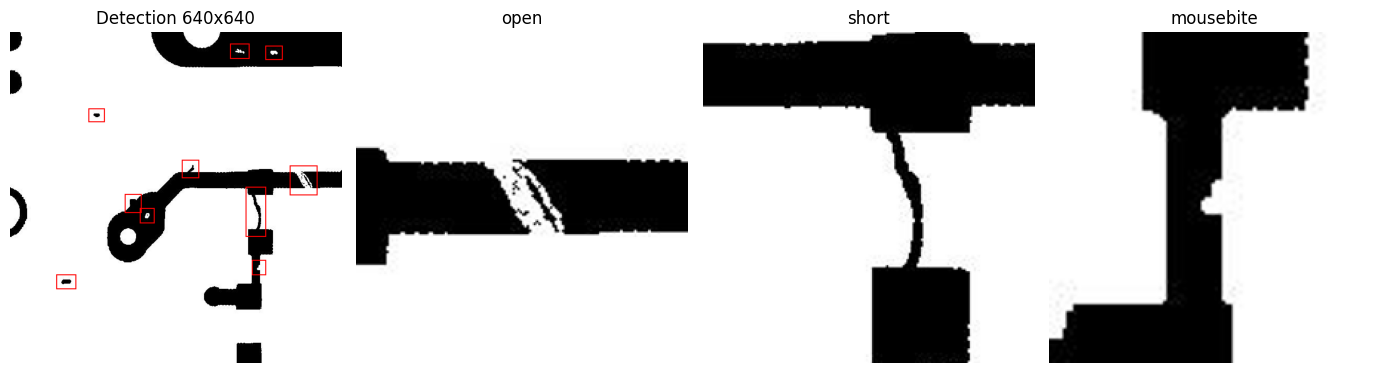

In [25]:
sample = detection_annotations.iloc[0]
selected_image = detection_manifest[
    (detection_manifest["split"] == sample["split"]) &
    (detection_manifest["image_name"] == sample["image_name"])
].iloc[0]

with Image.open(DETECT_ROOT / selected_image["image_path"]) as img:
    preview = img.convert("RGB")

draw = ImageDraw.Draw(preview)
selected_boxes = detection_annotations[
    (detection_annotations["split"] == sample["split"]) &
    (detection_annotations["image_name"] == sample["image_name"])
]
for _, box in selected_boxes.iterrows():
    draw.rectangle((int(box["x1"]), int(box["y1"]),
                    int(box["x2"]), int(box["y2"])), outline="red", width=2)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(preview)
axes[0].set_title("Detection 640x640")
axes[0].axis("off")

for i in range(3):
    axes[i + 1].axis("off")
    if i < len(crop_manifest):
        row = crop_manifest.iloc[i]
        with Image.open(CROP_ROOT / row["crop_path"]) as crop:
            axes[i + 1].imshow(crop)
        axes[i + 1].set_title(row["class_name"])

plt.tight_layout()
plt.show()

## 10. Summary

- **Detection:** `Data/processed/detection/` for YOLO training.
- **Classification:** `Data/processed/classification/` for CNN training.

In [26]:
print("PREPROCESSING RESULTS")
for split in SPLITS:
    n_images = len(detection_manifest[detection_manifest["split"] == split])
    n_boxes = len(detection_annotations[detection_annotations["split"] == split])
    n_crops = len(crop_manifest[crop_manifest["split"] == split])
    print(f"{split}: {n_images} images, {n_boxes} boxes, {n_crops} crops")

print("Detection:", DETECT_ROOT / "data.yaml")
print("Classification:", CROP_ROOT / "classification_manifest.csv")

PREPROCESSING RESULTS
train: 1199 images, 8015 boxes, 8015 crops
valid: 150 images, 1005 boxes, 1005 crops
test: 150 images, 984 boxes, 984 crops
Detection: Data\processed\detection\data.yaml
Classification: Data\processed\classification\classification_manifest.csv
